### Analysis of changes over time
The notebook visualizes the trends of e-scooter trips according to different time periods. Firstly, it takes into account the variation in e-scooter trips characteristics during the different times of the day, of the week, and of the year. It also divides trips into quartiles according to the hours of the day and allows to plot them separately. 
Successively, it considers how new regulation at the city level concerning e-scooter usage and stops may have impacted the trips, allowing to visualize trends of the period before and after the entry into force of the rules. 
Finally, it considers how Covid-19 have impacted e-scooter usage, taking into account the times of the most important events and laws enforced at a national level.

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import holoviews as hv
import hvplot.pandas
import random 

In [2]:
df = pd.read_parquet('../data/tripsv3_cleaned.parquet')
df = df.sort_values(by=['trip_start']).reset_index(drop=True)

In [3]:
df.head()

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id
0,BIT,3S4423,2020-11-30 14:32:20+00:00,2020-11-30 15:23:13+00:00,50.866667,46.069790,11.121222,46.069786,11.115813,3930.000000,NaN,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30
1,BIT,3S4155,2020-11-30 15:37:44+00:00,2020-11-30 15:46:11+00:00,8.450000,46.070271,11.120379,46.068718,11.115568,1000.000000,NaN,00001d90-0000-1000-8b30-5b7d6a617b60_2020-11-30
2,BIT,3S5078,2020-11-30 15:42:50+00:00,2020-11-30 15:49:39+00:00,6.800000,46.067200,11.126792,46.066917,11.120408,1180.000000,NaN,0000210d-0000-1000-8d7d-5b7d6a617b60_2020-11-30
3,BIT,3S4737,2020-11-30 16:01:31+00:00,2020-11-30 16:03:28+00:00,1.950000,46.069771,11.121225,46.069794,11.121309,0.000000,NaN,00000735-0000-1000-9635-5b7d6a617b60_2020-11-30
4,BIT,3S4196,2020-11-30 16:04:42+00:00,2020-11-30 16:12:06+00:00,7.400000,46.069771,11.121268,46.081554,11.121297,1430.000000,NaN,00000e00-0000-1000-9ab0-5b7d6a617b60_2020-11-30


In [3]:
days = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df['weekday'] = [days[df.at[i, 'trip_start'].weekday()] for i in range(len(df))]

In [4]:
df.groupby(['weekday'])['weekday'].aggregate('count')

weekday
Friday       17043
Monday       15377
Saturday     14791
Sunday       11834
Thursday     16547
Tuesday      16026
Wednesday    16523
Name: weekday, dtype: int64

In [5]:
df['date'] = pd.to_datetime(df['trip_start']).dt.date
df['trip_length'] = df.trip_length.astype(float)

In [6]:
df['trip_duration_minutes'] = [round((df.at[i,'trip_end']-df.at[i,'trip_start']).total_seconds()/60, 0) for i in range(len(df))]

In [7]:
def trend_per_weekday(df, weekday, y): # y takes either 'trip_length' or 'trip_duration_minutes'
    df = df[df.weekday==weekday]

    data = df.groupby(['date','operator']).agg({y: ['sum']}).reset_index() 
    data.columns = data.columns.droplevel(1)
    
    t = "Trips on "+str(weekday)+'s'
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)

In [8]:
trend_per_weekday(df, 'Thursday', 'trip_duration_minutes')

:NdOverlay   [operator]
   :Curve   [date]   (trip_duration_minutes)

In [10]:
trend_per_weekday(df, 'Sunday', 'trip_duration_minutes')

:NdOverlay   [operator]
   :Curve   [date]   (trip_duration_minutes)

In [11]:
df['day'] = [df.at[i,'date'].day for i in range(len(df))]

In [12]:
week_num=[]
for i in range(len(df)):
    if df.at[i,'day'] <= 7:
        week_num.append('1st')
    elif df.at[i,'day'] > 7 and df.at[i, 'day'] <=14:
        week_num.append('2nd')
    elif df.at[i, 'day'] > 14 and df.at[i,'day'] <=21:
        week_num.append('3rd')
    else:
        week_num.append('4th')
df['week_num'] = week_num

In [13]:
def trend_per_week_of_month(df, week_num, y): 
    '''
    y takes either 'trip_length' or 'trip_duration_minutes'
    '''
    df = df[df.week_num==week_num]
    data = df.groupby(['date']).agg({y: ['sum']}).reset_index() 
    data.columns = data.columns.droplevel(1)
    data['operator'] = ['overall']*len(data)

    data_by_op = df.groupby(['date', 'operator']).agg({y:['sum']}).reset_index()
    data_by_op.columns = data_by_op.columns.droplevel(1)
    data = pd.concat([data_by_op, data], ignore_index=True)

    t = "Trips on "+str(week_num)+' week of the month'
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)

In [14]:
trend_per_week_of_month(df, '1st', 'trip_duration_minutes')

:NdOverlay   [operator]
   :Curve   [date]   (trip_duration_minutes)

In [15]:
trend_per_week_of_month(df, '1st', 'trip_length')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

In [16]:
m = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
df['month'] = [m[df.at[i,'trip_start'].month] for i in range(len(df))]
df['year'] = [df.at[i,'date'].year for i in range(len(df))]

In [17]:
def trend_per_month(df, month, year, y):
    '''
    y takes either 'trip_length' or 'trip_duration_minutes'
    '''
    df = df.loc[(df.month==month) & (df.year==year)]
    data = df.groupby(['date']).agg({y: ['sum']}).reset_index() 
    data.columns = data.columns.droplevel(1)
    data['operator'] =['overall']*len(data)

    data_by_op = df.groupby(['date','operator']).agg({y: ['sum']}).reset_index()
    data_by_op.columns = data_by_op.columns.droplevel(1)
    data = pd.concat([data_by_op, data], ignore_index=True)

    t = "Trips on "+str(month)
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)

In [18]:
trend_per_month(df, 'April', 2021, 'trip_duration_minutes')

:NdOverlay   [operator]
   :Curve   [date]   (trip_duration_minutes)

In [19]:
df['hour'] = [df.at[i, 'trip_start'].hour for i in range(len(df))]

In [20]:
def weekday_per_h(df, weekday, h, y):

    df = df.loc[(df.weekday==weekday)&(df.hour==h)]

    data = df.groupby(['date']).agg({y:['sum']}).reset_index()
    data.columns = data.columns.droplevel(1)
    data['operator'] = ['overall']*len(data)

    data_by_op = df.groupby(['date', 'operator']).agg({y:['sum']}).reset_index()
    data_by_op.columns = data_by_op.columns.droplevel(1)
    data = pd.concat([data_by_op, data], ignore_index=True)

    t = "Trips on "+str(weekday)+'s between '+str(h)+':00-'+str(h)+':59'
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)
    

In [21]:
weekday_per_h(df,'Monday',8,'trip_length')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

In [22]:
def trip_per_h(df, h, y):

    df = df.loc[(df.hour==h)]

    data = df.groupby(['date']).agg({y:['sum']}).reset_index()
    data.columns = data.columns.droplevel(1)
    data['operator'] = ['overall']*len(data)

    data_by_op = df.groupby(['date', 'operator']).agg({y:['sum']}).reset_index()
    data_by_op.columns = data_by_op.columns.droplevel(1)
    data = pd.concat([data_by_op, data], ignore_index=True)

    t = 'Trips between '+str(h)+':00-'+str(h)+':59'
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)
    

In [23]:
trip_per_h(df, 22, 'trip_length')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

In [24]:
df.head(1)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id,weekday,date,trip_duration_minutes,day,week_num,month,year,hour
0,BIT,3S4423,2020-11-30 14:32:20+00:00,2020-11-30 15:23:13+00:00,50.866667,46.069790,11.121222,46.069786,11.115813,3930.0,NaN,00000bf0-0000-1000-a6a0-5b7d6a617b60_2020-11-30,Monday,2020-11-30,51.0,30,4th,November,2020,14


In [25]:
df.hvplot.violin(y='trip_length', by='month', c='month', ylabel='trip length',
                legend=False, width=900, height=500, padding=0.4)

:Violin   [month]   (trip_length)

In [26]:
df.hvplot.violin(y='trip_duration_minutes', by='month', c='month', ylabel='trip length',
                legend=False, width=900, height=500, padding=0.4)

:Violin   [month]   (trip_duration_minutes)

In [27]:
df.hvplot.violin(y='trip_duration_minutes', ylabel='trip length', width=300, height=500, padding=0.4)

:Violin   (trip_duration_minutes)

In [28]:
df.hvplot.violin(y='trip_length', by='weekday', c='weekday', ylabel='trip length',
                legend=False, width=900, height=500, padding=0.4)

:Violin   [weekday]   (trip_length)

In [29]:
df.hvplot.violin(y='trip_duration_minutes', by='weekday', c='weekday', ylabel='trip length',
                legend=False, width=900, height=500, padding=0.4)

:Violin   [weekday]   (trip_duration_minutes)

### Quantiles

In [30]:
df['time'] = [df.at[i,'trip_start'].time() for i in range(len(df))]

In [31]:
df = df.sort_values(by=['time']).reset_index(drop=True)

In [32]:
df.quantile([.25, .5, .75, 1], interpolation='nearest', numeric_only=False)['time']

0.25    10:23:51
0.50    14:06:44
0.75    17:16:01
1.00    23:59:55
Name: time, dtype: object

In [33]:
q = df.quantile([.25, .5, .75, 1], interpolation='nearest', numeric_only=False)

In [34]:
def data_per_quantile(df, qnt, y):
    df = df.sort_values(by=['date']).reset_index(drop=True)

    if qnt == 0.25:
        df = df.loc[df.time <= q.at[0.25, 'time']]
    elif qnt == 0.5:
        df = df.loc[(df.time > q.at[0.25,'time'])&(df.time <= q.at[0.5,'time'])]
    elif qnt == 0.75:
        df = df.loc[(df.time > q.at[0.5,'time'])&(df.time <= q.at[0.75,'time'])]
    elif qnt == 1.00:
        df = df.loc[(df.time > q.at[0.75, 'time'])]

    data = df.groupby(['date']).agg({y:['sum']}).reset_index()
    data.columns = data.columns.droplevel(1)
    data['operator'] = ['overall']*len(data)

    data_by_op = df.groupby(['date', 'operator']).agg({y:['sum']}).reset_index()
    data_by_op.columns = data_by_op.columns.droplevel(1)
    data = pd.concat([data_by_op, data], ignore_index=True)

    t = 'Trips quantile '+str(qnt)
    return data.hvplot(x='date', by='operator', y=y, line_width=2, title=t)

In [35]:
data_per_quantile(df, 0.25, 'trip_length')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

### Ordinanze
Ordinanze per regolamentare la sosta del monopattini elettrici:

- ordinanza 1366/2020/27 (blu nella [mappa](https://www.comune.trento.it/content/download/1307937/12545700/file/MONOPATTINI_punti%20sosta%20monopattini_A1%20allungato.pdf)): 2 dicembre 2020

- ordinanza 1419/2020/27 (azzurro): 22 dicembre 2020

- ordinanza 432/2022/27 (verde): 12 Aprile 2022

In [36]:
df = df.sort_values(by=['trip_start']).reset_index(drop=True)

In [37]:
# prima ordinanza
df.loc[(df['date']==dt.date(2020,12,2))]
# trend nella settimana dopo la prima ordinanza
ord_one = df.loc[(df['date']>=dt.date(2020,12,2))&(df['date']<=dt.date(2020,12,9))]
ord_one = ord_one.groupby(['date', 'operator']).agg({'trip_length':['sum']}).reset_index()
ord_one.columns = ord_one.columns.droplevel(1)
ord_one.hvplot(x='date', by='operator', y='trip_length', line_width=2, title='7 days after first regulation change')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

In [38]:
p = trend_per_month(df, 'December', 2020, 'trip_length')
p = p*hv.VLine(dt.date(2020,12,2)) # prima ordinanza
p = p*hv.VLine(dt.date(2020,12,22)) # seconda ordinanza
p

:Overlay
   .NdOverlay.I :NdOverlay   [operator]
      :Curve   [date]   (trip_length)
   .VLine.I     :VLine   [x,y]
   .VLine.II    :VLine   [x,y]

In [39]:
trend_per_month(df, 'January', 2021, 'trip_length')

:NdOverlay   [operator]
   :Curve   [date]   (trip_length)

In [40]:
p = trend_per_month(df, 'April', 2022, 'trip_length')
p = p*hv.VLine(dt.date(2022,4,12)) # terza ordinanza
p 

:Overlay
   .NdOverlay.I :NdOverlay   [operator]
      :Curve   [date]   (trip_length)
   .VLine.I     :VLine   [x,y]

In [41]:
data_by_op = df.groupby(['date', 'operator']).agg({'trip_length':['sum']}).reset_index()
data_by_op.columns = data_by_op.columns.droplevel(1)
data = df.groupby(['date']).agg({'trip_length':['sum']}).reset_index()
data.columns = data.columns.droplevel(1)
data['operator'] = ['overall']*len(data)
data = pd.concat([data, data_by_op], ignore_index=True)
p = data.hvplot(x='date', by='operator', y='trip_length')
p = p*hv.VLine(dt.date(2020,12,2)) # prima ordinanza
p = p*hv.VLine(dt.date(2020,12,22)) # seconda ordinanza
p = p*hv.VLine(dt.date(2022,4,12)) # terza ordinanza
p

:Overlay
   .NdOverlay.I :NdOverlay   [operator]
      :Curve   [date]   (trip_length)
   .VLine.I     :VLine   [x,y]
   .VLine.II    :VLine   [x,y]
   .VLine.III   :VLine   [x,y]

### Covid-19: storico contagi, ricoveri e decessi in Trentino
Secondo quanto riscontrabile al seguente [link](https://covid19trentino.fbk.eu/), in Trentino (e in particolar modo nell'area di Trento), i periodi di maggior intensità dell'emergenza sanitaria sono i seguenti:
- **massimo numero di contagi al giorno**: periodo `29/12/2021 - 08/02/2022`, con picchi più elevati in corrispondenza del 14/01/2022 e del 24/01/2022
- **periodi ad alto tasso di ricoveri**: periodo `11/03/2020 - 26/5/2020`, con picchi il 30/3/2020 e l' 8/4/2020, periodo `17/10/2020 - 1/05/2021`, con picchi il 23/11/2020, 9/12/2020, 3/1/2021 e 29/3/2021, e infine, anche se di entità decisamente inferiore, periodo `26/11/2021 - 13/3/2022`, con lieve picco intorno al 5/2/2022
- **periodo ad alto tasso di decessi**:` 20/3/2020 - 1/5/2020`, con picco intorno al 31/3/2020 e periodo `1/11/2020 - 2/2/2021`, con picco intorno al 18/12/2020

Inoltre, i periodi di lockdown e le fasi dell'emergenza sanitaria a livello nazionale sono:
- **lockdown**: 9/03/2020 - 18/05/2020
- **allentamento misure di contenimento**: 4/05/2020 - 14/06/2020
- convivenza con il covid: 15/06/2020 - 7/10/2020
- **nuove misure restrittive**: 8/10/2020 - 5/11/2020
- **coprifuoco** dalle ore 22.00 alle 5.00 del mattino e istituzione zone gialle, arancioni, rosse: dal 6/12/2021
- **misure restrittive periodo natalizio**: 21/12/2020 - 15/01/2021
- istituzione zone bianche: dal 16/1/2021
- inasprimento misure contenimento: 6/03/2021 - 25/04/2021
- **obbligo di certificazione verde**: dal 6/08/2021
- fine stato di emergenza: 1/04/2022

(Dati estratti da [wikipedia](https://it.wikipedia.org/wiki/Gestione_della_pandemia_di_COVID-19_in_Italia#Nuove_restrizioni_e_green_pass_vaccinale_(6_dicembre_2021_-_31_marzo_2022)) in data 16/06/2022)

In [42]:
# periods
before = df[df.date<=dt.date(2021, 12, 29)]
picco_contagi = df.loc[(df.date>dt.date(2021, 12, 29))&(df.date<=dt.date(2022, 2, 8))]
after = df[(df.date>dt.date(2022, 2, 8))]
# aggregate
def aggregate_df(df):
    df = df.groupby(['date']).agg({'trip_length':['sum'], 'trip_duration_minutes':['sum']})
    df.columns = df.columns.droplevel([1])
    return df.reset_index()

before = aggregate_df(before)
picco_contagi = aggregate_df(picco_contagi)
after = aggregate_df(after)

In [43]:
avg_before = before.trip_length.sum() / len(before)
avg_picco = picco_contagi.trip_length.sum() / len(picco_contagi)
avg_after = after.trip_length.sum() / len(after)

In [44]:
event = [avg_before, avg_picco, avg_after]
avg_data = dict(
    start=[before.date.min(), dt.date(2021,12,29), dt.date(2022,2,8)],
    end=[dt.date(2021,12,29), dt.date(2022,2,8), after.date.max()],   
    start_event = event,
    end_event = event
)

In [45]:
max_cont_plt = before.hvplot(x='date', y='trip_length', label='situazione pre-covid').opts(width=1000, height=400)
max_cont_plt = max_cont_plt * picco_contagi.hvplot(x='date', y='trip_length', label='massimo contagio')
max_cont_plt = max_cont_plt * after.hvplot(x='date', y='trip_length', label='abbassamento contagi')
max_cont_plt = max_cont_plt * hv.Segments(avg_data, [hv.Dimension('start'), hv.Dimension('start_event'), 'end', 'end_event'], label='distanza percorsa in media').opts(color='gray', line_dash='dashed')
max_cont_plt = max_cont_plt * hv.VLine(dt.date(2021,12,29)).opts(color='gray', line_width=1.5, line_dash='dashed')
max_cont_plt = max_cont_plt * hv.VLine(dt.date(2022,2,8)).opts(color='gray', line_width=1.5, line_dash='dashed')
# picchi 14/01/2022 e 24/01/2022:
max_cont_plt = max_cont_plt * hv.Spikes(([dt.date(2022,1,14), dt.date(2022,1,24)], [345741,258609]), vdims='height', label='picchi contagi').opts(color='darkred', line_width=2.0)
max_cont_plt.relabel("Impatto contagi Covid-19 sulla lunghezza dei viaggi").opts(legend_position='top_left')

:Overlay
   .Curve.Situazione_pre_hyphen_minus_covid :Curve   [date]   (trip_length)
   .Curve.Massimo_contagio                  :Curve   [date]   (trip_length)
   .Curve.Abbassamento_contagi              :Curve   [date]   (trip_length)
   .Segments.Distanza_percorsa_in_media     :Segments   [start,start_event,end,end_event]
   .VLine.I                                 :VLine   [x,y]
   .VLine.II                                :VLine   [x,y]
   .Spikes.Picchi_contagi                   :Spikes   [x]   (height)

In [46]:
avg_before = before.trip_duration_minutes.sum() / len(before)
avg_picco = picco_contagi.trip_duration_minutes.sum() / len(picco_contagi)
avg_after = after.trip_duration_minutes.sum() / len(after)
event = [avg_before, avg_picco, avg_after]
avg_data = dict(
    start=[before.date.min(), dt.date(2021,12,29), dt.date(2022,2,8)],
    end=[dt.date(2021,12,29), dt.date(2022,2,8), after.date.max()],   
    start_event = event,
    end_event = event
)
max_cont_plt = before.hvplot(x='date', y='trip_duration_minutes', label='situazione pre-covid').opts(width=1000, height=400)
max_cont_plt = max_cont_plt * picco_contagi.hvplot(x='date', y='trip_duration_minutes', label='massimo contagio')
max_cont_plt = max_cont_plt * after.hvplot(x='date', y='trip_duration_minutes', label='abbassamento contagi')
max_cont_plt = max_cont_plt * hv.Segments(avg_data, [hv.Dimension('start'), hv.Dimension('start_event'), 'end', 'end_event'], label='minuti medi percorsi').opts(color='gray', line_dash='dashed')
max_cont_plt = max_cont_plt * hv.VLine(dt.date(2021,12,29)).opts(color='gray', line_width=1.5, line_dash='dashed')
max_cont_plt = max_cont_plt * hv.VLine(dt.date(2022,2,8)).opts(color='gray', line_width=1.5, line_dash='dashed')
max_cont_plt = max_cont_plt * hv.Spikes(([dt.date(2022,1,14), dt.date(2022,1,24)], [1918,1377]), vdims='height', label='picchi contagi').opts(color='darkred', line_width=2.0)
max_cont_plt.relabel("Impatto contagi Covid-19 sulla durata delle corse").opts(legend_position='top_left')

:Overlay
   .Curve.Situazione_pre_hyphen_minus_covid :Curve   [date]   (trip_duration_minutes)
   .Curve.Massimo_contagio                  :Curve   [date]   (trip_duration_minutes)
   .Curve.Abbassamento_contagi              :Curve   [date]   (trip_duration_minutes)
   .Segments.Minuti_medi_percorsi           :Segments   [start,start_event,end,end_event]
   .VLine.I                                 :VLine   [x,y]
   .VLine.II                                :VLine   [x,y]
   .Spikes.Picchi_contagi                   :Spikes   [x]   (height)

**periodi ad alto tasso di ricoveri**: periodo `11/03/2020 - 26/5/2020`, con picchi il 30/3/2020 e l' 8/4/2020, periodo `17/10/2020 - 1/05/2021`, con picchi il 23/11/2020, 9/12/2020, 3/1/2021 e 29/3/2021, e infine, anche se di entità decisamente inferiore, periodo `26/11/2021 - 13/3/2022`, con lieve picco intorno al 5/2/2022

In [47]:
df.date.min() # dati e-scooter cominciano da Novembre 2020, quindi periodo di picco ricoveri compreso tra dt.date(2020, 11, 30) e dtdate(2021, 5, 1)

datetime.date(2020, 11, 30)

In [48]:
def aggregate_df(df):
    df = df.groupby(['date']).agg({'trip_length':['sum'], 'trip_duration_minutes':['sum'], 'date':['count']})
    df.columns = df.columns.droplevel([1])
    df.rename(columns = {'date':'num_trips'}, inplace = True)
    return df.reset_index()

def escooter_contagi(data_inizio_periodo, data_fine_periodo, y, label, picchi, plot_title):
    # periods
    before = df[df.date<=data_inizio_periodo]
    picco_contagi = df.loc[(df.date>data_inizio_periodo)&(df.date<=data_fine_periodo)]
    after = df[(df.date>data_fine_periodo)]
    # aggregate
    before = aggregate_df(before)
    picco_contagi = aggregate_df(picco_contagi)
    after = aggregate_df(after)
    # compute average
    avg_before = before[y].sum() / len(before)
    avg_picco = picco_contagi[y].sum() / len(picco_contagi)
    avg_after = after[y].sum() / len(after)
    event = [avg_before, avg_picco, avg_after]
    avg_data = dict(
        start=[before.date.min(), data_inizio_periodo, data_fine_periodo],
        end=[data_inizio_periodo, data_fine_periodo, after.date.max()],   
        start_event = event,
        end_event = event
    )
    max_cont_plt = before.hvplot(x='date', y=y, label='situazione pre-covid').opts(width=1000, height=400)
    max_cont_plt = max_cont_plt * picco_contagi.hvplot(x='date', y=y, label='massimo contagio')
    max_cont_plt = max_cont_plt * after.hvplot(x='date', y=y, label='abbassamento contagi')
    max_cont_plt = max_cont_plt * hv.Segments(avg_data, [hv.Dimension('start'), hv.Dimension('start_event'), 'end', 'end_event'], label=label).opts(color='gray', line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.VLine(data_inizio_periodo).opts(color='gray', line_width=1.5, line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.VLine(data_fine_periodo).opts(color='gray', line_width=1.5, line_dash='dashed')
    max_cont_plt = max_cont_plt * hv.Spikes((picchi, [avg_picco]*len(picchi)), vdims='height', label='picchi contagi').opts(color='darkred', line_width=2.0)
    return max_cont_plt.relabel(plot_title).opts(legend_position='top_left')

# picchi: 23/11/2020, 9/12/2020, 3/1/2021 e 29/3/2021
escooter_contagi(dt.date(2020, 11, 30), dt.date(2021, 5, 1), 'trip_duration_minutes', 'minuti medi percorsi', [dt.date(2020, 11, 23), dt.date(2020, 12, 9), dt.date(2021, 1, 3), dt.date(2021, 3, 29)], "Impatto ricoveri per Covid-19 sulla durata delle corse")
escooter_contagi(dt.date(2020, 11, 30), dt.date(2021, 5, 1), 'trip_length', 'distanza percorsa in media', [dt.date(2020, 11, 23), dt.date(2020, 12, 9), dt.date(2021, 1, 3), dt.date(2021, 3, 29)], "Impatto ricoveri per Covid-19 sulla distanza percorsa")

# periodo 26/11/2021 - 13/3/2022, con lieve picco intorno al 5/2/2022
escooter_contagi(dt.date(2021, 11, 26), dt.date(2022, 3, 13), 'num_trips', 'distanza percorsa in media', [dt.date(2022, 2, 5)], "Impatto ricoveri per Covid-19 sul numero di corse")


:Overlay
   .Curve.Situazione_pre_hyphen_minus_covid :Curve   [date]   (num_trips)
   .Curve.Massimo_contagio                  :Curve   [date]   (num_trips)
   .Curve.Abbassamento_contagi              :Curve   [date]   (num_trips)
   .Segments.Distanza_percorsa_in_media     :Segments   [start,start_event,end,end_event]
   .VLine.I                                 :VLine   [x,y]
   .VLine.II                                :VLine   [x,y]
   .Spikes.Picchi_contagi                   :Spikes   [x]   (height)

In [49]:
escooter_contagi(dt.date(2021, 11, 26), dt.date(2022, 3, 13), 'trip_length', 'distanza percorsa in media', [dt.date(2022, 2, 5)], "Impatto ricoveri per Covid-19 sulla durata delle corse")

:Overlay
   .Curve.Situazione_pre_hyphen_minus_covid :Curve   [date]   (trip_length)
   .Curve.Massimo_contagio                  :Curve   [date]   (trip_length)
   .Curve.Abbassamento_contagi              :Curve   [date]   (trip_length)
   .Segments.Distanza_percorsa_in_media     :Segments   [start,start_event,end,end_event]
   .VLine.I                                 :VLine   [x,y]
   .VLine.II                                :VLine   [x,y]
   .Spikes.Picchi_contagi                   :Spikes   [x]   (height)

- **periodo ad alto tasso di decessi**: `20/3/2020 - 1/5/2020`, con picco intorno al 31/3/2020 e periodo `1/11/2020 - 2/2/2021`, con picco picco intorno al 18/12/2020

In [50]:
df.date.min()

datetime.date(2020, 11, 30)

In [51]:
escooter_contagi(dt.date(2020, 11, 30), dt.date(2021, 2, 2), 'trip_length', 'distanza percorsa in media', [dt.date(2020, 12, 18)], "Impatto decessi per Covid-19")

:Overlay
   .Curve.Situazione_pre_hyphen_minus_covid :Curve   [date]   (trip_length)
   .Curve.Massimo_contagio                  :Curve   [date]   (trip_length)
   .Curve.Abbassamento_contagi              :Curve   [date]   (trip_length)
   .Segments.Distanza_percorsa_in_media     :Segments   [start,start_event,end,end_event]
   .VLine.I                                 :VLine   [x,y]
   .VLine.II                                :VLine   [x,y]
   .Spikes.Picchi_contagi                   :Spikes   [x]   (height)

Fasi dell'emergenza sanitaria a livello nazionale:
- **lockdown**: 9/03/2020 - 18/05/2020
- **allentamento misure di contenimento**: 4/05/2020 - 14/06/2020
- convivenza con il covid: 15/06/2020 - 7/10/2020
- **nuove misure restrittive**: 8/10/2020 - 5/11/2020
- **coprifuoco** dalle ore 22.00 alle 5.00 del mattino e istituzione zone gialle, arancioni, rosse: dal 6/12/2021
- **misure restrittive periodo natalizio**: 21/12/2020 - 15/01/2021
- istituzione zone bianche: dal 16/1/2021
- inasprimento misure contenimento: 6/03/2021 - 25/04/2021
- **obbligo di certificazione verde**: dal 6/08/2021
- fine stato di emergenza: 1/04/2022

In [52]:
def aggregate_df(df):
    df = df.groupby(['date']).agg({'trip_length':['sum'], 'trip_duration_minutes':['sum'], 'date':['count']})
    df.columns = df.columns.droplevel([1])
    df.rename(columns = {'date':'num_trips'}, inplace = True)
    return df.reset_index()

def covid_livello_nazionale(df, y, date_emergenza, plot_title):
    avg = df[y].sum() / len(df)
    max_cont_plt = df.hvplot(x='date', y=y, label='andamento utilizzo monopattini elettrici').opts(width=1500, height=500)
    max_cont_plt = max_cont_plt * hv.HLine(avg).opts(color='orange', line_dash='dashed')
    for data_naz in date_emergenza:
        c = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]
        if data_naz[0]>=df.date.min():
            height = df_agg.at[np.where(df_agg.date==data_naz[0])[0][0], y]
            max_cont_plt = max_cont_plt * hv.Spikes((data_naz[0], [height]), vdims='height', label=data_naz[1]).opts(color=c[0], line_width=2.0, line_dash='dashed')
    return max_cont_plt.relabel(plot_title).opts(legend_position='top_left') 

df_agg = aggregate_df(df)
date_emergenza = [ [dt.date(2020,3,9), 'inizio lockdown'], [dt.date(2020,5,15), 'fine lockdown'], [dt.date(2020,5,4), 'allentamento misure contenimento'],
                [dt.date(2020,10,8), 'nuove misure restrittive'], [dt.date(2021,12,6), 'coprifuoco e zone gialle, arancioni, rosse'], [dt.date(2020,12,21), 'inizio misure restrittive periodo natalizio'],
                [dt.date(2021,1,15), 'fine misure restrittive periodo natalizio'], [dt.date(2021,1,16), 'istituzione zone bianche'], [dt.date(2021,3,6), 'nuove misure contenimento'], 
                [dt.date(2021,4,25), 'fine misure contenimento'], [dt.date(2021,8,6), 'obbligo certificazione verde'], [dt.date(2022,4,1), 'fine stato di emergenza']]
covid_livello_nazionale(df_agg, 'trip_length', date_emergenza, 'Variazione distanza percorsa in e-scooter durante l\'emergenza sanitaria')

:Overlay
   .Curve.Andamento_utilizzo_monopattini_elettrici              :Curve   [date]   (trip_length)
   .HLine.I                                                     :HLine   [x,y]
   .Spikes.Coprifuoco_e_zone_gialle_comma_arancioni_comma_rosse :Spikes   [x]   (height)
   .Spikes.Inizio_misure_restrittive_periodo_natalizio          :Spikes   [x]   (height)
   .Spikes.Fine_misure_restrittive_periodo_natalizio            :Spikes   [x]   (height)
   .Spikes.Istituzione_zone_bianche                             :Spikes   [x]   (height)
   .Spikes.Nuove_misure_contenimento                            :Spikes   [x]   (height)
   .Spikes.Fine_misure_contenimento                             :Spikes   [x]   (height)
   .Spikes.Obbligo_certificazione_verde                         :Spikes   [x]   (height)
   .Spikes.Fine_stato_di_emergenza                              :Spikes   [x]   (height)

In [53]:
covid_livello_nazionale(df_agg, 'num_trips', date_emergenza, 'Variazione distanza percorsa in e-scooter durante l\'emergenza sanitaria')

:Overlay
   .Curve.Andamento_utilizzo_monopattini_elettrici              :Curve   [date]   (num_trips)
   .HLine.I                                                     :HLine   [x,y]
   .Spikes.Coprifuoco_e_zone_gialle_comma_arancioni_comma_rosse :Spikes   [x]   (height)
   .Spikes.Inizio_misure_restrittive_periodo_natalizio          :Spikes   [x]   (height)
   .Spikes.Fine_misure_restrittive_periodo_natalizio            :Spikes   [x]   (height)
   .Spikes.Istituzione_zone_bianche                             :Spikes   [x]   (height)
   .Spikes.Nuove_misure_contenimento                            :Spikes   [x]   (height)
   .Spikes.Fine_misure_contenimento                             :Spikes   [x]   (height)
   .Spikes.Obbligo_certificazione_verde                         :Spikes   [x]   (height)
   .Spikes.Fine_stato_di_emergenza                              :Spikes   [x]   (height)

In [54]:
def aggregate_by_h(df):
    df = df.groupby(['hour']).agg({'trip_length':['sum'], 'trip_duration_minutes':['sum'], 'date':['count']})
    df.columns = df.columns.droplevel([1])
    df.rename(columns = {'date':'trips_count'}, inplace = True)
    return df.reset_index()

In [55]:
# - **coprifuoco** dalle ore 22.00 alle 5.00 del mattino e istituzione zone gialle, arancioni, rosse: dal 6/12/2021
pre_coprifuoco = df.loc[(df.date<dt.date(2021,12,6))].reset_index(drop=True)
post_coprifuoco = df.loc[(df.date>=dt.date(2021,12,6))].reset_index(drop=True)

df_pre_weekday = pre_coprifuoco[pre_coprifuoco.weekday.isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])].reset_index(drop=True)
df_pre_weekday = aggregate_by_h(df_pre_weekday)
df_pre_weekend = pre_coprifuoco[pre_coprifuoco.weekday.isin(['Saturday','Sunday'])].reset_index(drop=True)
df_pre_weekend = aggregate_by_h(df_pre_weekend)
df_post_weekday = post_coprifuoco[post_coprifuoco.weekday.isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])].reset_index(drop=True)
df_post_weekday = aggregate_by_h(df_post_weekday)
df_post_weekend = post_coprifuoco[post_coprifuoco.weekday.isin(['Saturday','Sunday'])].reset_index(drop=True)
df_post_weekend = aggregate_by_h(df_post_weekend)

def andamento_weekday_weekend_coprifuoco(y):
    p = df_pre_weekday.hvplot(x='hour', y=y, label='Pre-Coprifuoco, Weekdays')#.opts(width=1500, height=500)
    p = p * df_post_weekday.hvplot(x='hour', y=y, label='Post-Coprifuoco, Weekdays')
    max_post_weekday = df_post_weekday.at[np.where(df_post_weekday[y]==df_post_weekday[y].max())[0][0], 'hour']
    p = p * hv.Spikes((max_post_weekday, [df_post_weekday[y].max()]), vdims='height', label='ora di maggior utilizzo').opts(color='darkred', line_width=2.0, line_dash='dashed')
    max_pre_weekday = df_pre_weekday.at[np.where(df_pre_weekday[y]==df_pre_weekday[y].max())[0][0], 'hour']
    p = p * hv.Spikes((max_pre_weekday, [df_pre_weekday[y].max()]), vdims='height', label='ora di maggior utilizzo').opts(color='darkred', line_width=2.0, line_dash='dashed')

    p2 = df_pre_weekend.hvplot(x='hour', y=y, label='Pre-Coprifuoco, Weekends').opts(color='gold')
    p2 = p2 * df_post_weekend.hvplot(x='hour', y=y, label='Post-Coprifuoco, Weekends').opts(color='orange')
    max_post_weekend = df_post_weekend.at[np.where(df_post_weekend[y]==df_post_weekend[y].max())[0][0], 'hour']
    p2 = p2 * hv.Spikes((max_post_weekend, [df_post_weekend[y].max()]), vdims='height', label='ora di maggior utilizzo').opts(color='red', line_width=2.0, line_dash='dashed')
    max_pre_weekend = df_pre_weekend.at[np.where(df_pre_weekend[y]==df_pre_weekend[y].max())[0][0], 'hour']
    p2 = p2 * hv.Spikes((max_pre_weekend, [df_pre_weekend[y].max()]), vdims='height', label='ora di maggior utilizzo').opts(color='red', line_width=2.0, line_dash='dashed')

    return p.relabel('Andamento E-Scooter durante la Settimana').opts(legend_position='top_left') + p2.relabel('Andamento E-Scooter nei Weekends').opts(legend_position='top_left') 

andamento_weekday_weekend_coprifuoco('trip_length')
# andamento_weekday_weekend_coprifuoco('trip_duration_minutes')
# andamento_weekday_weekend_coprifuoco('trips_count')

:Layout
   .Overlay.Andamento_E_hyphen_minus_Scooter_durante_la_Settimana :Overlay
      .Curve.Pre_hyphen_minus_Coprifuoco_comma_Weekdays  :Curve   [hour]   (trip_length)
      .Curve.Post_hyphen_minus_Coprifuoco_comma_Weekdays :Curve   [hour]   (trip_length)
      .Spikes.Ora_di_maggior_utilizzo.I                  :Spikes   [x]   (height)
      .Spikes.Ora_di_maggior_utilizzo.II                 :Spikes   [x]   (height)
   .Overlay.Andamento_E_hyphen_minus_Scooter_nei_Weekends         :Overlay
      .Curve.Pre_hyphen_minus_Coprifuoco_comma_Weekends  :Curve   [hour]   (trip_length)
      .Curve.Post_hyphen_minus_Coprifuoco_comma_Weekends :Curve   [hour]   (trip_length)
      .Spikes.Ora_di_maggior_utilizzo.I                  :Spikes   [x]   (height)
      .Spikes.Ora_di_maggior_utilizzo.II                 :Spikes   [x]   (height)

In [56]:
andamento_weekday_weekend_coprifuoco('trips_count')

:Layout
   .Overlay.Andamento_E_hyphen_minus_Scooter_durante_la_Settimana :Overlay
      .Curve.Pre_hyphen_minus_Coprifuoco_comma_Weekdays  :Curve   [hour]   (trips_count)
      .Curve.Post_hyphen_minus_Coprifuoco_comma_Weekdays :Curve   [hour]   (trips_count)
      .Spikes.Ora_di_maggior_utilizzo.I                  :Spikes   [x]   (height)
      .Spikes.Ora_di_maggior_utilizzo.II                 :Spikes   [x]   (height)
   .Overlay.Andamento_E_hyphen_minus_Scooter_nei_Weekends         :Overlay
      .Curve.Pre_hyphen_minus_Coprifuoco_comma_Weekends  :Curve   [hour]   (trips_count)
      .Curve.Post_hyphen_minus_Coprifuoco_comma_Weekends :Curve   [hour]   (trips_count)
      .Spikes.Ora_di_maggior_utilizzo.I                  :Spikes   [x]   (height)
      .Spikes.Ora_di_maggior_utilizzo.II                 :Spikes   [x]   (height)

### Spatial Analysis, pre- and post- curfew

In [168]:
import seaborn as sns
import contextily as ctx
import matplotlib.pyplot as plt
import geopandas as gpd
import datashader as ds
from pointpats import centrography, QStatistic, PointPattern
from sklearn.cluster import DBSCAN

In [68]:
pre_coprifuoco = gpd.GeoDataFrame(pre_coprifuoco, crs='EPSG:4326', geometry=gpd.points_from_xy(pre_coprifuoco.trip_origin_longitude, pre_coprifuoco.trip_origin_latitude))
pre_coprifuoco['x'] = pre_coprifuoco.to_crs(epsg=3857).geometry.x
pre_coprifuoco['y'] = pre_coprifuoco.to_crs(epsg=3857).geometry.y
pre_coprifuoco.trip_origin_latitude = pre_coprifuoco.trip_origin_latitude.astype(float)
pre_coprifuoco.trip_origin_longitude = pre_coprifuoco.trip_origin_longitude.astype(float)

post_coprifuoco = gpd.GeoDataFrame(post_coprifuoco, crs='EPSG:4326', geometry=gpd.points_from_xy(post_coprifuoco.trip_origin_longitude, post_coprifuoco.trip_origin_latitude))
post_coprifuoco['x'] = post_coprifuoco.to_crs(epsg=3857).geometry.x
post_coprifuoco['y'] = post_coprifuoco.to_crs(epsg=3857).geometry.y
post_coprifuoco.trip_origin_latitude = post_coprifuoco.trip_origin_latitude.astype(float)
post_coprifuoco.trip_origin_longitude = post_coprifuoco.trip_origin_longitude.astype(float)
post_coprifuoco = post_coprifuoco.reset_index(drop=True)

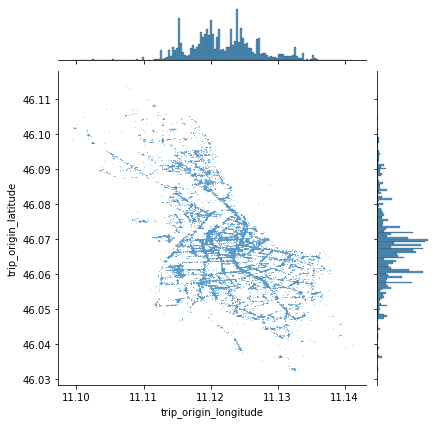

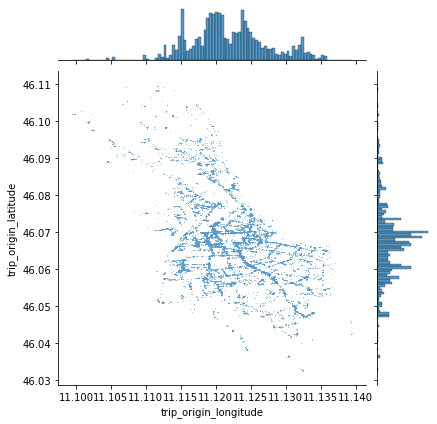

In [153]:
# scatter plot
sns.jointplot(x='trip_origin_longitude', y='trip_origin_latitude', data=pre_coprifuoco, s=0.5)
sns.jointplot(x='trip_origin_longitude', y='trip_origin_latitude', data=post_coprifuoco, s=0.5)

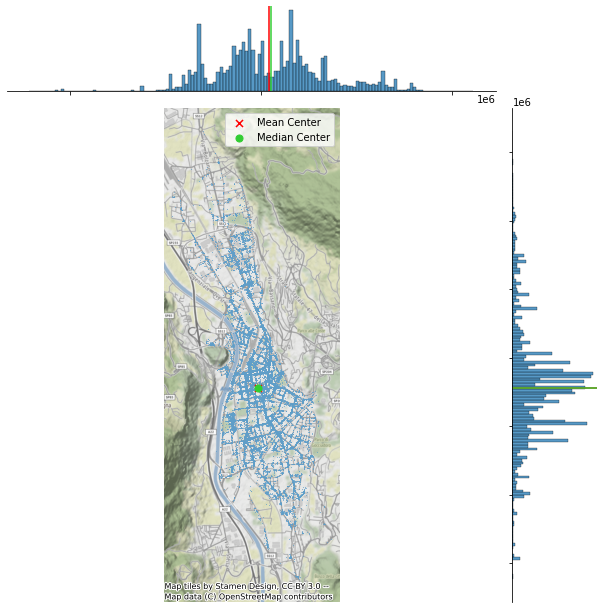

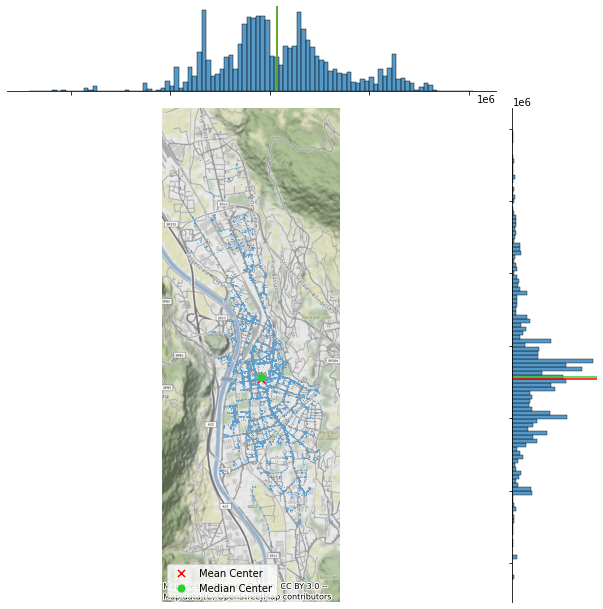

In [157]:
# Scatterplot with center of mass
def sc_center(df):
    mean_center = centrography.mean_center(df[['x', 'y']])
    med_center = centrography.euclidean_median(df[['x', 'y']])
    # Generate scatter plot
    joint_axes = sns.jointplot(
        x='x', y='y', data=df, s=0.75, height=9
    )
    # Add mean point and marginal lines
    joint_axes.ax_joint.scatter(
        *mean_center, color='red', marker='x', s=50, label='Mean Center'
    )
    joint_axes.ax_marg_x.axvline(mean_center[0], color='red')
    joint_axes.ax_marg_y.axhline(mean_center[1], color='red')
    # Add median point and marginal lines
    joint_axes.ax_joint.scatter(
        *med_center, color='limegreen', marker='o', s=50, label='Median Center'
    )
    joint_axes.ax_marg_x.axvline(med_center[0], color='limegreen')
    joint_axes.ax_marg_y.axhline(med_center[1], color='limegreen')
    # Legend
    joint_axes.ax_joint.legend()
    # Add basemap
    ctx.add_basemap(joint_axes.ax_joint) # source=ctx.providers.CartoDB.Positron
    # Clean axes
    joint_axes.ax_joint.set_axis_off()
    # Display
    plt.show()

sc_center(pre_coprifuoco); sc_center(post_coprifuoco)

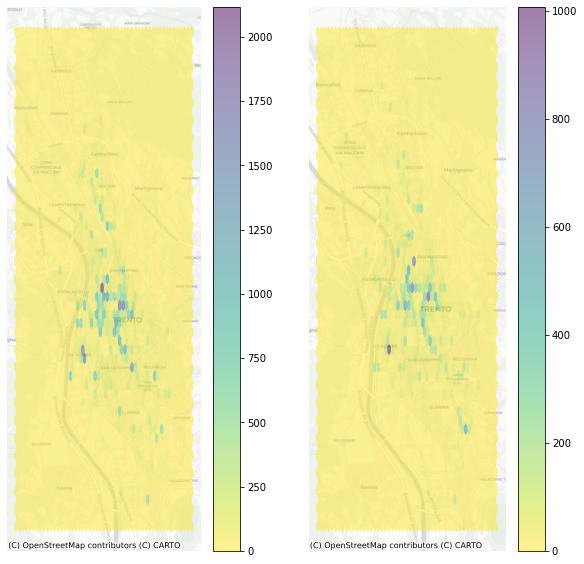

In [127]:
# Density with Hex-binning
def hexbin_density(ax, df):
    # Generate and add hexbin with 50 hexagons in each dimension
    hb = ax.hexbin(
        df['x'], 
        df['y'],
        gridsize=50, 
        linewidths=0,
        alpha=0.5, 
        cmap='viridis_r')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    # Add colorbar
    plt.colorbar(hb, ax=ax)
    # Remove axes
    ax.set_axis_off()

f, ax = plt.subplots(1,2, figsize=(10, 10))
hexbin_density(ax[0], pre_coprifuoco)
hexbin_density(ax[1], post_coprifuoco)

In [149]:
# based on trips origins
pre_coprifuoco['lon'], pre_coprifuoco['lat'] = ds.utils.lnglat_to_meters(pre_coprifuoco['trip_origin_longitude'], pre_coprifuoco['trip_origin_latitude'])
post_coprifuoco['lon'], post_coprifuoco['lat'] = ds.utils.lnglat_to_meters(post_coprifuoco['trip_origin_longitude'], post_coprifuoco['trip_origin_latitude'])

pre_coprifuoco.hvplot.hexbin(x='lon', y='lat', width=700, height=500, alpha=0.4, logz=True, tiles='EsriImagery') + post_coprifuoco.hvplot.hexbin(x='lon', y='lat', width=700, height=500, alpha=0.4, logz=True, tiles='EsriImagery')

:Layout
   .Overlay.I  :Overlay
      .Tiles.I    :Tiles   [x,y]
      .HexTiles.I :HexTiles   [lon,lat]
   .Overlay.II :Overlay
      .Tiles.I    :Tiles   [x,y]
      .HexTiles.I :HexTiles   [lon,lat]

In [171]:
coordinates_pre = []
for lon, lat in zip(pre_coprifuoco.trip_origin_longitude.to_list(), pre_coprifuoco.trip_origin_latitude.to_list()):
    coordinates_pre.append([lon, lat])

coordinates_post = []
for lon, lat in zip(post_coprifuoco.trip_origin_longitude.to_list(), post_coprifuoco.trip_origin_latitude.to_list()):
    coordinates_post.append([lon, lat])

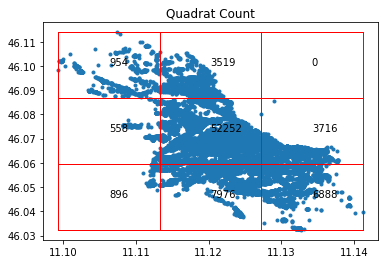

In [173]:
# Examine the spatial distribution of points in an area in terms of the count of observations that fall within a given cell
# pre-curfew
qstat = QStatistic(PointPattern(coordinates_pre))
qstat.plot()

In [ ]:
QStatistic(PointPattern(coordinates_pre), shape='rectangle', nx=4, ny=4)
QStatistic(PointPattern(coordinates_pre), shape='hexagon')

In [176]:
# for a 3x3 grid, the central cell has 52252 observations, while the surrounding ones have way fewer: this means the chi-squared test 
# (which compares how likely this distribution is if the cell counts are uniform) 
# will be statistically significant, with a very small p-value
qstat.chi2_pvalue

0.0

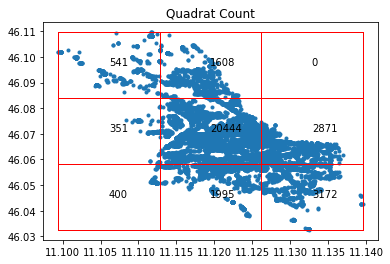

In [175]:
# post-curfew
QStatistic(PointPattern(coordinates_post)).plot()

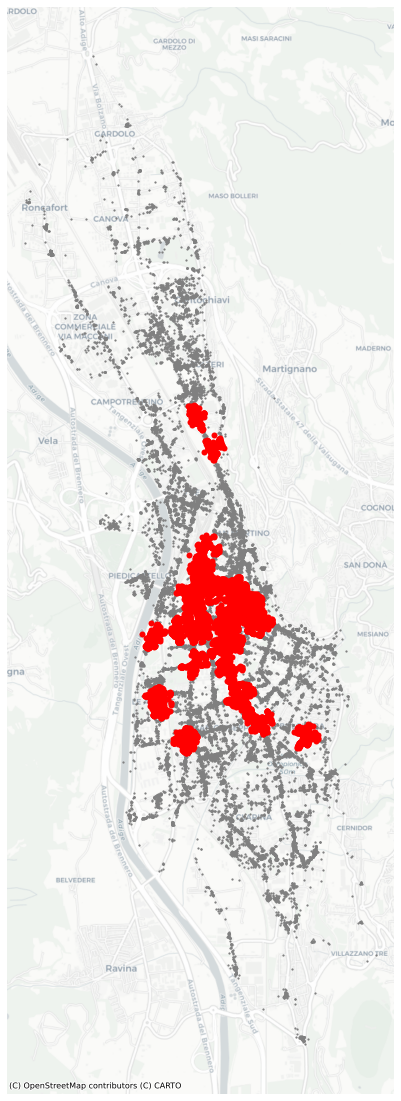

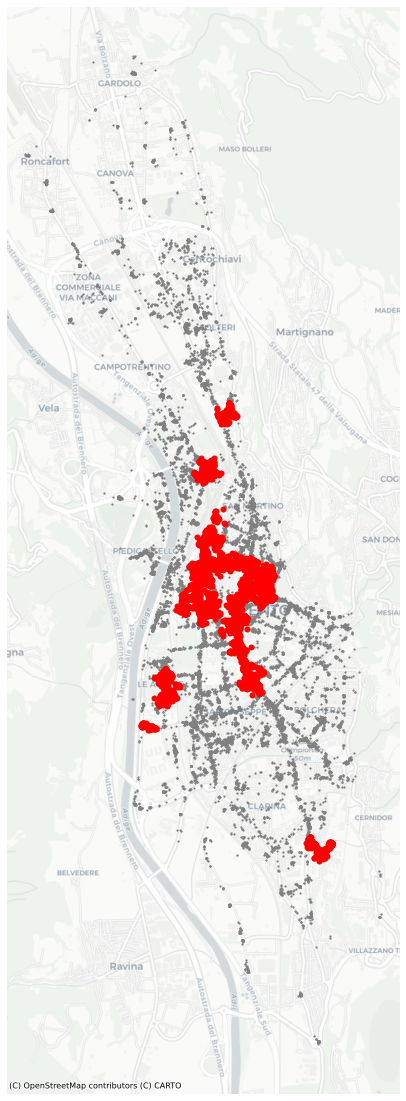

In [200]:
def dbscan_clustering (df):
    # get more general patterns, by setting min_samples (a cluster needs to have at least 1% of all the points in the dataset)
    # and expand the maximum radius to 100 meters
    # (otherwise the majority of the points will be classified as noise)
    clusterer = DBSCAN(eps = 100, min_samples = np.round(df.shape[0] * 0.01)) 
    # fit data
    clusterer.fit(df[["x", "y"]])

    lbls = pd.Series(clusterer.labels_, index=df.index)

    # Setup figure and axis
    f, ax = plt.subplots(1, figsize=(20, 20))
    # Subset points that are not part of any cluster (noise)
    noise = df.loc[lbls==-1, ['x', 'y']]
    # Plot noise in grey
    ax.scatter(noise['x'], noise['y'], c='grey', s=5, linewidth=0)
    # Plot all points that are not noise in red:
    # take the index of all points and substract from it the index of those that are noise
    ax.scatter(df.loc[df.index.difference(noise.index), 'x'], \
            df.loc[df.index.difference(noise.index), 'y'], \
            c='red', linewidth=0)
    # add basemap
    ctx.add_basemap(
        ax, 
        source=ctx.providers.CartoDB.Positron
    )

    ax.set_axis_off()
    plt.show()

dbscan_clustering(pre_coprifuoco)
dbscan_clustering(post_coprifuoco)

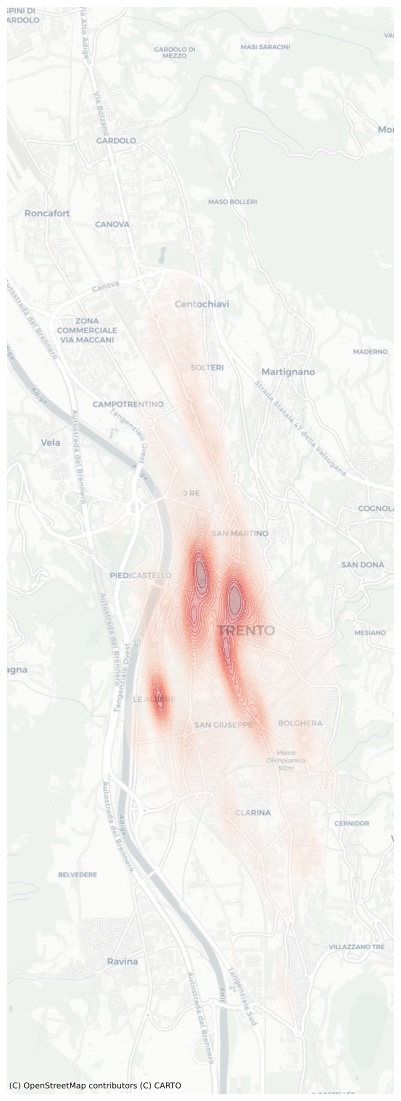

In [213]:
f, ax = plt.subplots(1, figsize=(20, 20))
# Kernel Density Estimation, pre-coprifuoco
ax = sns.kdeplot(x=pre_coprifuoco['x'], y=pre_coprifuoco['y'],
                n_levels=30, shade=True,
                alpha=0.3, cmap='Reds')
# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# Remove axes
ax.set_axis_off()

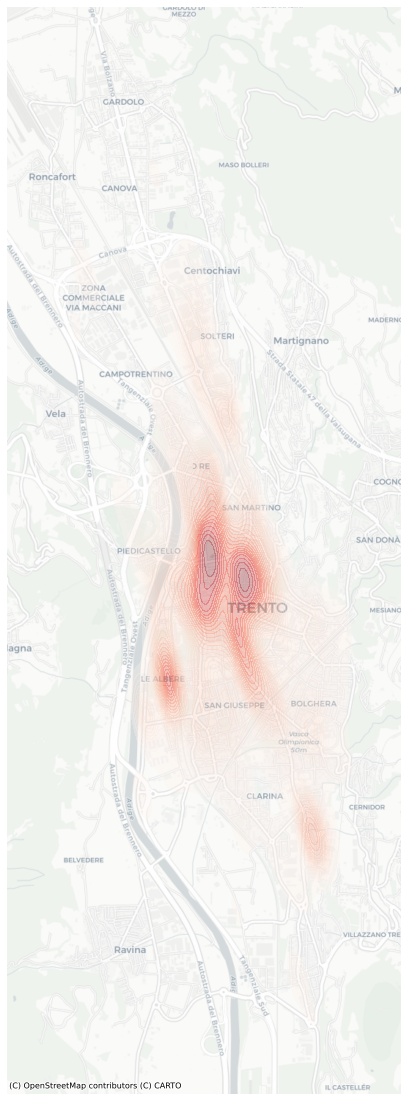

In [212]:
f, ax = plt.subplots(1, figsize=(20, 20))
# KDE, post-coprifuoco
ax = sns.kdeplot(x=post_coprifuoco['x'], y=post_coprifuoco['y'],
                n_levels=30, shade=True,
                alpha=0.3, cmap='Reds')
# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# Remove axes
ax.set_axis_off()